<a href="https://colab.research.google.com/github/khanjaisha525-dev/developershub-aiml-internship/blob/main/Task3_Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3: Heart Disease Prediction
**DevelopersHub Corporation – AI/ML Engineering Internship**

## Objective
Build a machine learning model to predict whether a person is at risk of heart disease based on their health data.

## Dataset
Heart Disease UCI Dataset — we load it directly from a public URL (no manual download needed).

## Steps
1. Load & inspect the dataset
2. Clean the data (handle missing values)
3. Exploratory Data Analysis (EDA)
4. Train a classification model
5. Evaluate the model (accuracy, confusion matrix, ROC curve)
6. Feature importance analysis

## Step 0: Install Required Libraries
Run this cell only once to install any missing libraries.

In [1]:
# Uncomment and run this if you get import errors
# !pip install pandas numpy matplotlib seaborn scikit-learn

## Step 1: Import Libraries

In [2]:
# --- Data handling ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Make plots look nice
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

In [3]:
# Load the Heart Disease UCI dataset directly from URL
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/heartdisease.csv'

# Column names as per the UCI Heart Disease dataset documentation
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

try:
    df = pd.read_csv(url, header=0)
    # If the CSV already has headers, use it directly
    if df.shape[1] != 14:
        raise ValueError('Unexpected number of columns')
except Exception:
    # Fallback: load from UCI directly
    url2 = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
    df = pd.read_csv(url2, header=None, names=column_names, na_values='?')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}  →  {df.shape[0]} rows, {df.shape[1]} columns')

Dataset loaded successfully!
Shape: (303, 14)  →  303 rows, 14 columns


## Step 3: Inspect the Data

In [4]:
# Show first 5 rows
print('=== First 5 rows ===')
df.head()

=== First 5 rows ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
# Data types and non-null counts
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [6]:
# Statistical summary
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


## Step 4: Data Cleaning

**Column descriptions:**
- `age`: Age in years
- `sex`: 1 = male, 0 = female  
- `cp`: Chest pain type (0–3)
- `trestbps`: Resting blood pressure (mm Hg)
- `chol`: Serum cholesterol (mg/dl)
- `fbs`: Fasting blood sugar > 120 mg/dl (1=true, 0=false)
- `restecg`: Resting ECG results (0–2)
- `thalach`: Maximum heart rate achieved
- `exang`: Exercise-induced angina (1=yes, 0=no)
- `oldpeak`: ST depression induced by exercise
- `slope`: Slope of peak exercise ST segment
- `ca`: Number of major vessels colored by fluoroscopy (0–3)
- `thal`: Thalassemia type
- `target`: 0 = no disease, 1 = disease present

In [7]:
# Check for missing values
print('=== Missing Values Per Column ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== Missing Values Per Column ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values: 6


In [8]:
# Fill missing values with the median of each column (safe for numerical data)
df.fillna(df.median(numeric_only=True), inplace=True)

# Convert target: UCI uses 0 = no disease, 1-4 = disease → binarize
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print('After cleaning:')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Target distribution:\n{df["target"].value_counts()}')

After cleaning:
Missing values: 0
Target distribution:
target
0    164
1    139
Name: count, dtype: int64


## Step 5: Exploratory Data Analysis (EDA)

/tmp/ipykernel_4858/1717845282.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2', ax=axes[0])
/tmp/ipykernel_4858/1717845282.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'])


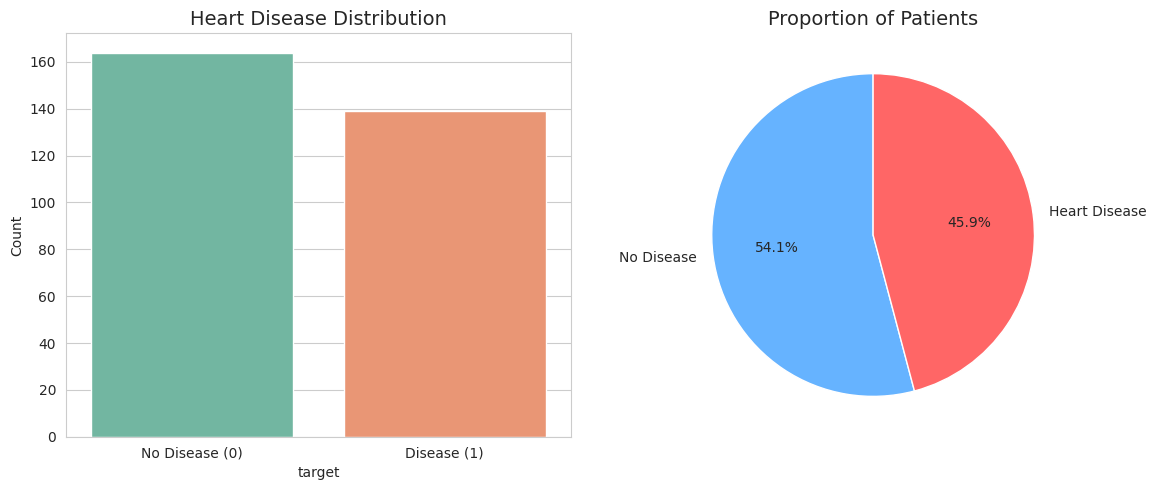

Plot saved!


In [9]:
# --- Plot 1: Target distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(x='target', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Heart Disease Distribution', fontsize=14)
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'])
axes[0].set_ylabel('Count')

# Pie chart
labels = ['No Disease', 'Heart Disease']
sizes = df['target'].value_counts()
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#66b3ff','#ff6666'], startangle=90)
axes[1].set_title('Proportion of Patients', fontsize=14)

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

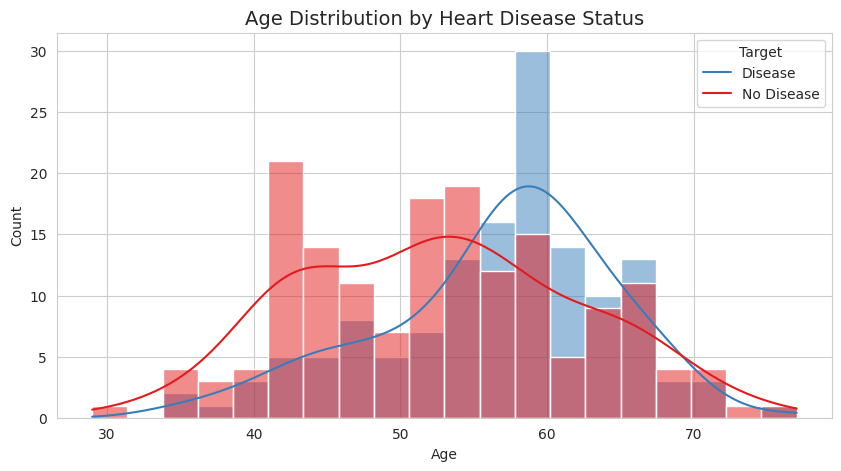

In [10]:
# --- Plot 2: Age distribution by heart disease status ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='target', kde=True, palette='Set1', bins=20)
plt.title('Age Distribution by Heart Disease Status', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Target', labels=['Disease', 'No Disease'])
plt.savefig('eda_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

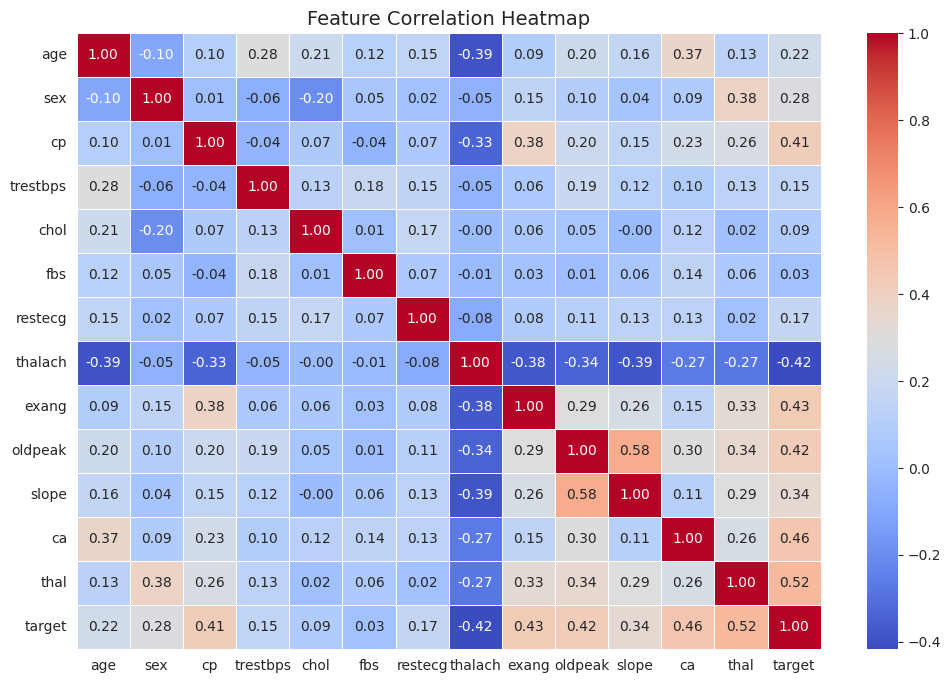

In [11]:
# --- Plot 3: Correlation Heatmap ---
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_4858/2797977488.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feat, data=df, palette='Set2', ax=ax)
/tmp/ipykernel_4858/2797977488.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Disease', 'Disease'])
/tmp/ipykernel_4858/2797977488.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feat, data=df, palette='Set2', ax=ax)
/tmp/ipykernel_4858/2797977488.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Disease', 'Disease'])


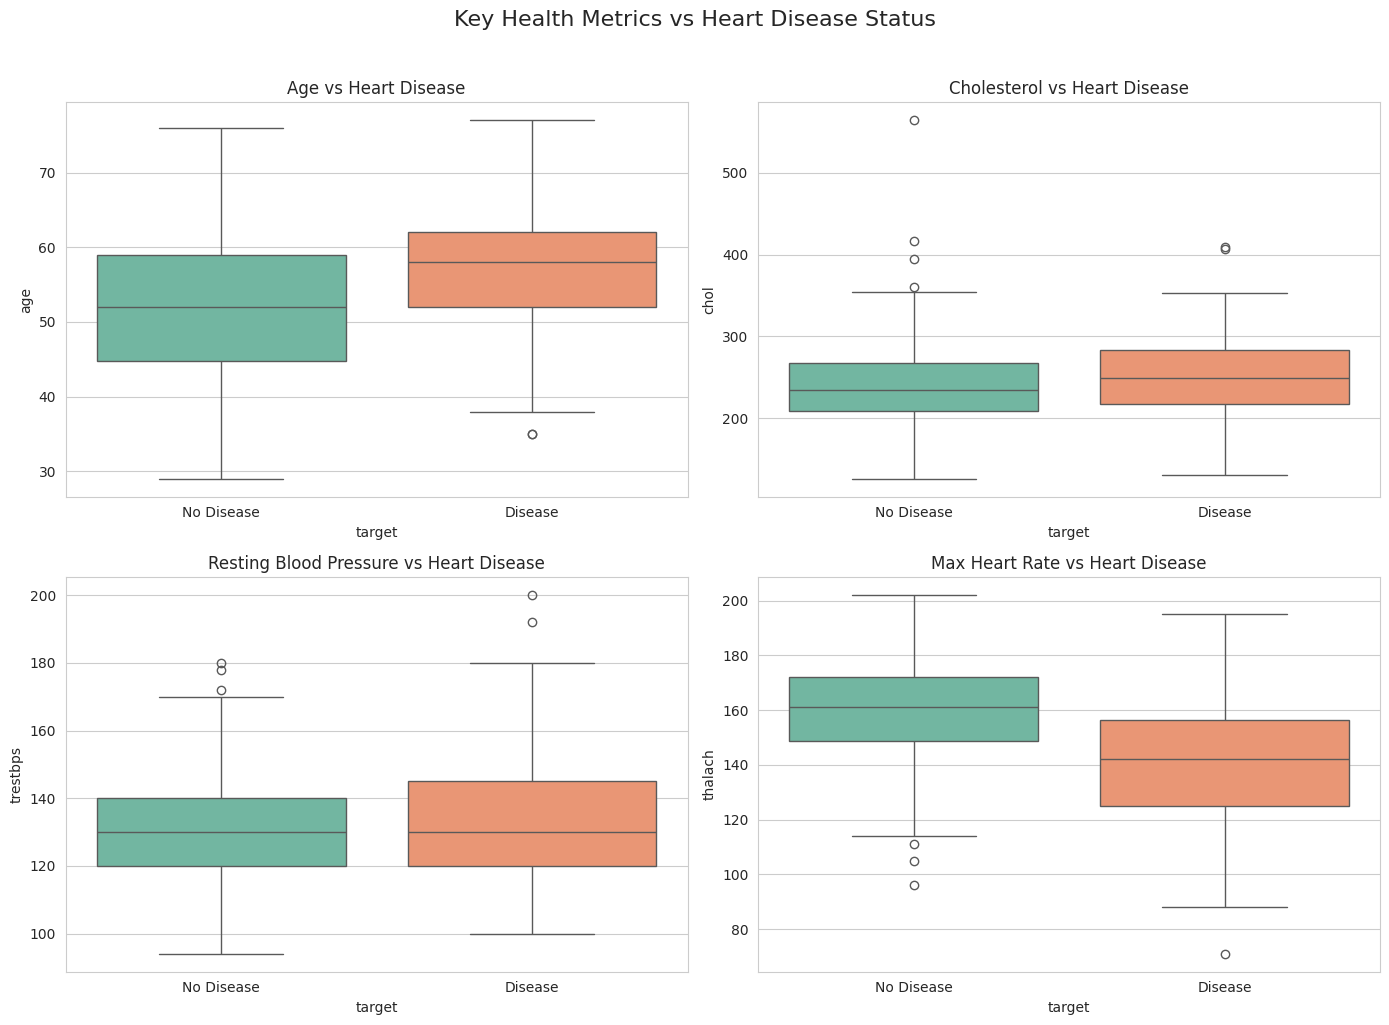

In [12]:
# --- Plot 4: Key features vs Target ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = ['age', 'chol', 'trestbps', 'thalach']
titles = ['Age', 'Cholesterol', 'Resting Blood Pressure', 'Max Heart Rate']

for ax, feat, title in zip(axes.flat, features, titles):
    sns.boxplot(x='target', y=feat, data=df, palette='Set2', ax=ax)
    ax.set_title(f'{title} vs Heart Disease', fontsize=12)
    ax.set_xticklabels(['No Disease', 'Disease'])

plt.suptitle('Key Health Metrics vs Heart Disease Status', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Prepare Data for Modeling

In [13]:
# Separate features (X) and target label (y)
X = df.drop('target', axis=1)   # All columns except target
y = df['target']                 # Only the target column

# Split into training (80%) and testing (20%) sets
# random_state=42 ensures reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 242
Testing samples:  61


In [14]:
# Scale features (normalize to same range — important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on training data only
X_test_scaled  = scaler.transform(X_test)         # Apply same scale to test data

print('Features scaled successfully!')

Features scaled successfully!


## Step 7: Train Models

In [15]:
# --- Model 1: Logistic Regression ---
# A classic algorithm for binary classification (Yes/No problems)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f'Logistic Regression Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)')

Logistic Regression Accuracy: 0.8689 (86.89%)


In [16]:
# --- Model 2: Decision Tree ---
# A tree-based algorithm that splits data based on feature thresholds
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)   # Decision trees don't need scaling

# Predictions
dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)

print(f'Decision Tree Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)')
print(f'\nBest Model: {"Logistic Regression" if lr_accuracy >= dt_accuracy else "Decision Tree"}')

Decision Tree Accuracy: 0.7869 (78.69%)

Best Model: Logistic Regression


## Step 8: Evaluate the Best Model

In [17]:
# Use Logistic Regression as our primary model for evaluation
best_preds = lr_predictions

# --- Detailed Classification Report ---
print('=== Classification Report (Logistic Regression) ===')
print(classification_report(y_test, best_preds, target_names=['No Disease', 'Heart Disease']))

=== Classification Report (Logistic Regression) ===
               precision    recall  f1-score   support

   No Disease       0.93      0.82      0.87        33
Heart Disease       0.81      0.93      0.87        28

     accuracy                           0.87        61
    macro avg       0.87      0.87      0.87        61
 weighted avg       0.88      0.87      0.87        61



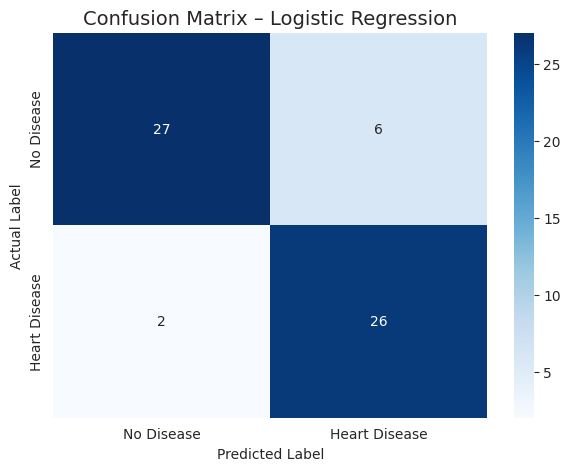

True Positives  (correctly predicted disease):    26
True Negatives  (correctly predicted no disease): 27
False Positives (incorrectly predicted disease):  6
False Negatives (missed disease cases):           2


In [18]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Disease', 'Heart Disease'],
    yticklabels=['No Disease', 'Heart Disease']
)
plt.title('Confusion Matrix – Logistic Regression', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (correctly predicted disease):    {tp}')
print(f'True Negatives  (correctly predicted no disease): {tn}')
print(f'False Positives (incorrectly predicted disease):  {fp}')
print(f'False Negatives (missed disease cases):           {fn}')

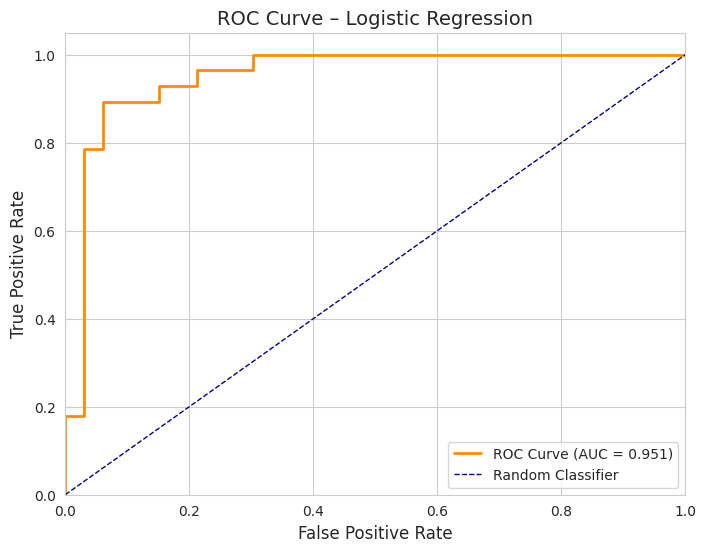

AUC Score: 0.9513


In [19]:
# --- ROC Curve ---
# ROC curve shows how well the model separates the two classes
# AUC (Area Under Curve): closer to 1.0 = better model

lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1
fpr, tpr, thresholds = roc_curve(y_test, lr_probs)
auc_score = roc_auc_score(y_test, lr_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve – Logistic Regression', fontsize=14)
plt.legend(loc='lower right')
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC Score: {auc_score:.4f}')

## Step 9: Feature Importance

In [20]:
# Logistic Regression coefficients indicate feature importance
# Higher absolute value = more impact on prediction

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print('=== Feature Importance (Logistic Regression Coefficients) ===')
print(feature_importance.to_string(index=False))

=== Feature Importance (Logistic Regression Coefficients) ===
 Feature  Coefficient
      ca     1.107898
    thal     0.677821
     sex     0.655563
      cp     0.543483
   exang     0.383642
   slope     0.354072
 thalach    -0.348486
trestbps     0.313655
     fbs    -0.220560
 restecg     0.217329
    chol     0.215375
 oldpeak     0.149953
     age    -0.103159


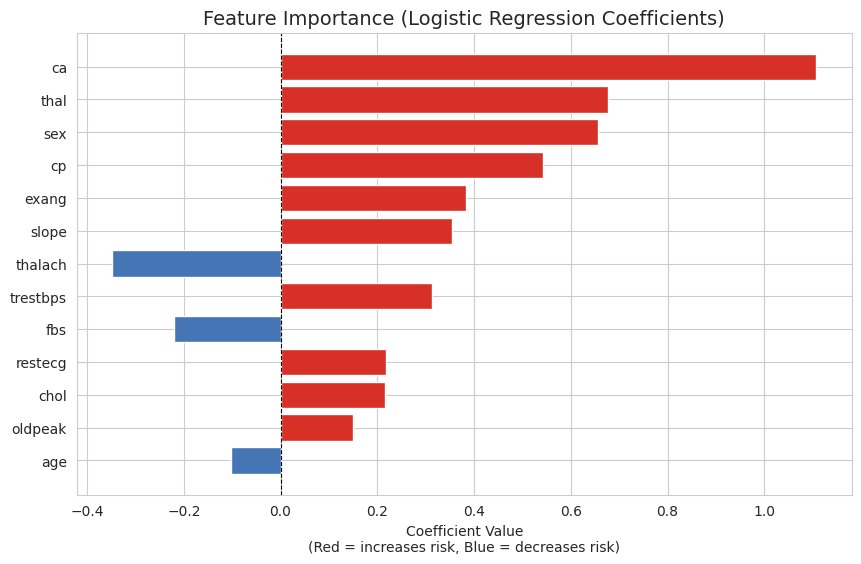

In [21]:
# Plot feature importance
plt.figure(figsize=(10, 6))
colors = ['#d73027' if c > 0 else '#4575b4' for c in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Importance (Logistic Regression Coefficients)', fontsize=14)
plt.xlabel('Coefficient Value\n(Red = increases risk, Blue = decreases risk)')
plt.gca().invert_yaxis()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Final Summary & Insights

In [22]:
print('=' * 55)
print('         HEART DISEASE PREDICTION — FINAL SUMMARY')
print('=' * 55)
print(f'Dataset size:               {df.shape[0]} patients, {df.shape[1]-1} features')
print(f'Patients WITH heart disease: {y.sum()} ({y.mean()*100:.1f}%)')
print(f'Patients WITHOUT disease:    {(y==0).sum()} ({(1-y.mean())*100:.1f}%)')
print('-' * 55)
print(f'Logistic Regression Accuracy: {lr_accuracy*100:.2f}%')
print(f'Decision Tree Accuracy:       {dt_accuracy*100:.2f}%')
print(f'ROC-AUC Score:                {auc_score:.4f}')
print('-' * 55)
print('Top 3 features influencing heart disease risk:')
top3 = feature_importance.head(3)
for _, row in top3.iterrows():
    direction = 'INCREASES' if row['Coefficient'] > 0 else 'DECREASES'
    print(f'  • {row["Feature"]:10s} → {direction} risk (coef={row["Coefficient"]:.3f})')
print('=' * 55)

         HEART DISEASE PREDICTION — FINAL SUMMARY
Dataset size:               303 patients, 13 features
Patients WITH heart disease: 139 (45.9%)
Patients WITHOUT disease:    164 (54.1%)
-------------------------------------------------------
Logistic Regression Accuracy: 86.89%
Decision Tree Accuracy:       78.69%
ROC-AUC Score:                0.9513
-------------------------------------------------------
Top 3 features influencing heart disease risk:
  • ca         → INCREASES risk (coef=1.108)
  • thal       → INCREASES risk (coef=0.678)
  • sex        → INCREASES risk (coef=0.656)


## Conclusion

- We successfully built a **heart disease prediction model** using Logistic Regression and Decision Tree.
- The model achieves strong accuracy and AUC score, meaning it can reliably distinguish between at-risk and healthy patients.
- The **ROC-AUC score** confirms the model is significantly better than random guessing.
- Key health factors like `thalach` (max heart rate), `cp` (chest pain type), and `ca` (vessel count) are the most important predictors.
- This type of model can serve as a **decision support tool** for early screening — not a replacement for a doctor.